In [ ]:
# 코랩에서 한글 설치하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 이거 실행 후 런타임 다시 시작


형태소 분석을 위한 환경 설정


In [ ]:
# mecab 참조: https://lsjsj92.tistory.com/612

!apt-get update
!apt-get install g++ openjdk-8-jdk python-dev python3-dev
!pip3 install JPype1-py3
!pip3 install konlpy
!JAVA_HOME="/usr/lib/jvm/java-8-openjdk-amd64"

In [ ]:
from konlpy.tag import Okt
okt = Okt()
print(okt.morphs('아버지가 방에 들어가신다'))

['아버지', '가', '방', '에', '들어가신다']


대통령 신년사 워드 클라우드 만들기

In [ ]:
from konlpy.tag import Okt
from nltk import Text
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
import warnings
warnings.simplefilter('ignore')

1. 파일 읽어오기

In [ ]:
f = open('/content/2022_신년사.txt')
texts = f.read()
f.close()

In [ ]:
texts[:50]

'존경하는 국민 여러분,\n\n2022년, 새해의 출발선에 다시 섰습니다. 격동하는 세계사의 한'

2. 읽어온 데이터를 이용해 형태소 단위로 분류하기
 - 명사 / 동사 / 형용사만 추출하기

In [ ]:
okt=Okt()
okt.morphs(texts) #단어 단위로 분류하기
pos_txt=okt.pos(texts)

#명사만 빼오기
nn = [t[0] for t in pos_txt if t[1 == "Noun"]]
# 동사
verb = [t[0] for t in pos_txt if t[1 == "Verb"]]
# 형용사
adj = [t[0] for t in pos_txt if t[1 == "Adjective"]]

nn[:5]
verb[:5]
adj[:5]

['존경', '하는', '국민', '여러분', ',']

3. 분류한 데이터 하나로 합친 뒤 Text를 이용해 NLTK.text로 만들기

In [ ]:
morph = nn + verb + adj
print(morph[:10])
morph_T = Text(morph)
morph_T

['존경', '하는', '국민', '여러분', ',', '\n\n', '2022년', ',', '새해', '의']


<Text: 존경 하는 국민 여러분 , 

 2022년 ,...>

4. 토큰(단어) 빈도수 그래프로 출력하기

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

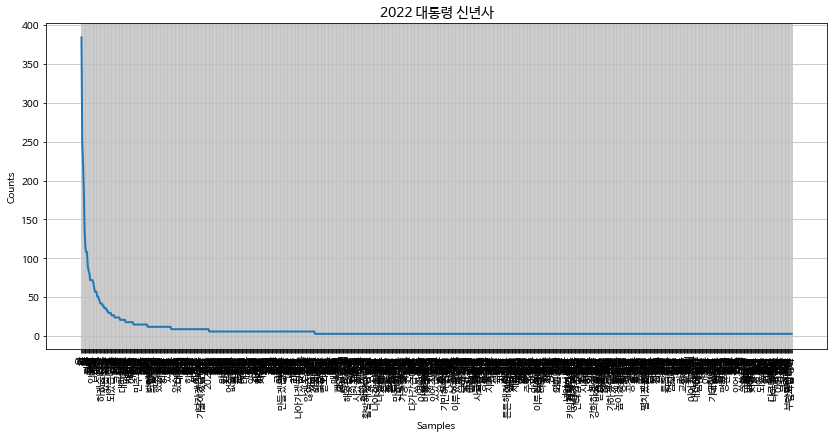

In [ ]:
plt.figure(figsize=(14,6))
plt.title('2022 대통령 신년사', size = 14)
morph_T.plot()
plt.show()

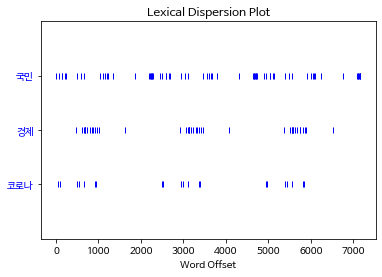

In [ ]:
morph_T.dispersion_plot(['국민','경제','코로나']) # 단어의 위치 추적
plt.show()

### morph의 고유 단어 추출 및 빈도수 계산
- 고유 단어 추출
- 추출 단어를 이용한 단어별 빈도수
- 해당 결과를 리스트에 (단어, 빈도수) 튜플 구조로 저장

빈도 계산 및 워드 클라우드 작성

### 불용어(Stop_Word) 처리
- 영문 사전: 영문은 기본 제공
- 한글 사전: 개인적으로 만들어 써야 함
- 사전 참조: https://www.ranks.nl/stopwords


In [ ]:
# 사용자 stop_words 사용하기 (한글인 경우 무조건 만들어야 됨)
stop_words = ', \n\n 여러분 우리 있는 모든 국민 속 하는 하며 하고 되고 로 으로 맞습니다 들 인 고 며 간 드립니다 깊은 것 도 하여 감사 와 길 까지 한 면 된 섰습니다 에 에서 됐습니다 과 더 을 의 를 가 이 될 해야 합니다 은 는 있습니다 를 했습니다 하겠습니다 수 할 위 해 등 ? . ! 출발 선 다시 존경 새 입니다 되었습니다 더욱'
stop_words = stop_words.split(' ')
print(stop_words)

[',', '\n\n', '여러분', '우리', '있는', '모든', '국민', '속', '하는', '하며', '하고', '되고', '로', '으로', '맞습니다', '들', '인', '고', '며', '간', '드립니다', '깊은', '것', '도', '하여', '감사', '와', '길', '까지', '한', '면', '된', '섰습니다', '에', '에서', '됐습니다', '과', '더', '을', '의', '를', '가', '이', '될', '해야', '합니다', '은', '는', '있습니다', '를', '했습니다', '하겠습니다', '수', '할', '위', '해', '등', '?', '.', '!', '출발', '선', '다시', '존경', '새', '입니다', '되었습니다', '더욱']


In [ ]:
# 사용자 stopword 적용하기
# morph_sw = []
# for sw in morph:
#     if sw not in stop_words:
#         morph_sw.append(sw)

morph_sw = [ sw for sw in morph if sw not in stop_words]

print(morph[:10])
print(morph_sw[:10])

['존경', '하는', '국민', '여러분', ',', '\n\n', '2022년', ',', '새해', '의']
['2022년', '새해', '격동', '세계사', '복판', '굳건', '희망', '새해', '호랑이', '힘찬']


In [ ]:
# 빈도 수에 의한 워드 클라우드 출력

In [ ]:
print(okt.morph)

In [ ]:
morph_cnt = Counter(morph_sw)   # 리트에 입력된 데이터의 빈도수 계산
morph_cnt  # 딕셔너리 구조: {단어:빈도수, 단어:빈도수, ....}

Counter({"'": 30,
         '-': 15,
         '1': 3,
         '10': 6,
         '2': 6,
         '2022년': 6,
         '2년': 6,
         '3': 6,
         '3만': 6,
         '4': 6,
         '4만': 3,
         '50': 3,
         '52시간': 3,
         '5분': 3,
         '5천': 3,
         '6': 3,
         '7': 3,
         '70년': 3,
         'K': 21,
         'TOP': 3,
         '·': 9,
         '가격': 3,
         '가교': 3,
         '가는': 3,
         '가능한': 3,
         '가능합니다': 3,
         '가속': 3,
         '가야': 3,
         '가운데': 6,
         '가장': 9,
         '가족': 3,
         '가지는': 3,
         '가치': 3,
         '가하겠습니다': 3,
         '각': 3,
         '감사합니다': 3,
         '감소': 6,
         '강국': 12,
         '강도': 3,
         '강력히': 3,
         '강한': 12,
         '강화': 6,
         '강화하겠습니다': 3,
         '갖추게': 3,
         '개도국': 3,
         '개방': 3,
         '개선': 6,
         '개월': 3,
         '개척': 6,
         '개혁': 3,
         '거나': 3,
         '거대한': 3,
         '거듭': 6,
         '걸': 3,
      

In [ ]:
morph_txt = morph_cnt.most_common() # 딕셔너리 구조를 튜플형 구조로 변경
morph_txt[:10]

[('정부', 84),
 ('세계', 57),
 ('적', 57),
 ('국가', 45),
 ('경제', 42),
 ('위기', 33),
 ("'", 30),
 ('평화', 30),
 ('함께', 27),
 ('나라', 24)]

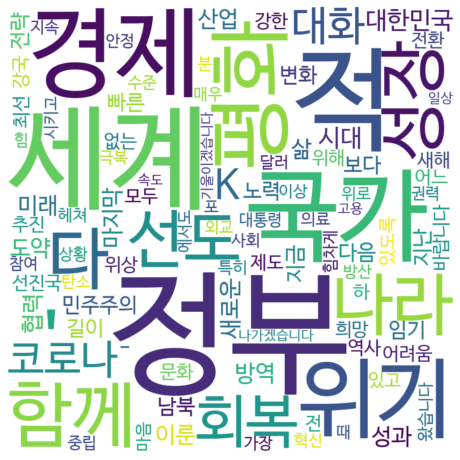

In [ ]:
## 빈도수가 낮은 데이터(빈도수 5 미만인 데이터) 제거
morph_txt_up = [tc for tc in morph_txt if tc[1] >= 5]

# 워드클라우드 작업을 위한 딕셔너리(튜플 = > 딕셔너리) 구조 변경
morph_txt_up = dict(morph_txt_up)

## 워드클라우드 출력
#font_path = './'
wordcloud = WordCloud(font_path = "NanumBarunGothic",
                      background_color='white',
                      width=1000, height=1000,
                      max_words=100, max_font_size=300)

# 틱셔너리 구조의 데이터를 이용해 워크클라우드 출력
wc = wordcloud.generate_from_frequencies(morph_txt_up)
plt.figure(figsize=(8, 15))
plt.imshow(wc)
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()

In [ ]:
import pandas as pd

# 빈도수가 5 이상인 데이터를 이용해 DataFrame로 출력

morph_txt_tu=[tc for tc in morph_txt if tc[1] >= 5]
df = pd.DataFrame(morph_txt_tu, columns=['단어', '빈도수'])
df

,단어,빈도수
0,정부,84
1,세계,57
2,적,57
3,국가,45
4,경제,42
...,...,...
234,통합,6
235,발전,6
236,였습니다,6
237,크게,6
